In [1]:
import matplotlib.pyplot as plt
from src.quantum_random_walk.quantum_random_walk import circle_quantum_random_walk_1D, noisy_meas_circle_quantum_random_walk_1D, noisy_circle_quantum_random_walk_1D
from src.random_walk.random_walk import random_walk
import numpy as np
import csv

def var_mu0(X, Y):
    X_arr = np.asarray(X)
    Y_arr = np.asarray(Y)
    return np.sum(Y_arr * (X_arr ** 2))

In [4]:
'''
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'X'

TIMES = 50
ALPHAS = []
P = []

for p in np.linspace(0, 1, 75):
    var_ft = []
    t = []
    #data, X = noisy_meas_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, 0, SEED)
    
    data, X = noisy_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, noise_type, p, None)
    np.random.seed(42)
    
    for i in range(20, 100, 10):
        t.append(i + 1)
        Y = data[i]
        var_ft.append(var_mu0(X,Y))

    log_t = np.log(t)
    log_var_ft = np.log(var_ft)
    alpha, log_C = np.polyfit(log_t, log_var_ft, 1)
    print(f'p noise: {p}, alpha: {alpha}')

    ALPHAS.append(alpha)
    P.append(p)

with open(f"./data/diffusion_alpha/{noise_type}.csv", "w") as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(P)
        csvwriter.writerow(ALPHAS)

plt.plot(P, ALPHAS)
'''

'\nSEED = 42\nsteps = 100\nmax_pos = 100\nsymm_qrw = True\nnoise_type = \'X\'\n\nTIMES = 50\nALPHAS = []\nP = []\n\nfor p in np.linspace(0, 1, 75):\n    var_ft = []\n    t = []\n    #data, X = noisy_meas_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, 0, SEED)\n\n    data, X = noisy_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, noise_type, p, None)\n    np.random.seed(42)\n\n    for i in range(20, 100, 10):\n        t.append(i + 1)\n        Y = data[i]\n        var_ft.append(var_mu0(X,Y))\n\n    log_t = np.log(t)\n    log_var_ft = np.log(var_ft)\n    alpha, log_C = np.polyfit(log_t, log_var_ft, 1)\n    print(f\'p noise: {p}, alpha: {alpha}\')\n\n    ALPHAS.append(alpha)\n    P.append(p)\n\nwith open(f"./data/diffusion_alpha/{noise_type}.csv", "w") as csvfile:\n        csvwriter = csv.writer(csvfile)\n        csvwriter.writerow(P)\n        csvwriter.writerow(ALPHAS)\n\nplt.plot(P, ALPHAS)\n'

p noise: 0.000, alpha: 2.0625
p noise: 0.010, alpha: 1.9393
p noise: 0.030, alpha: 1.6307
p noise: 0.040, alpha: 1.6695
p noise: 0.050, alpha: 1.5411
p noise: 0.070, alpha: 1.4033
p noise: 0.080, alpha: 1.4859
p noise: 0.090, alpha: 1.2616
p noise: 0.110, alpha: 1.3129
p noise: 0.120, alpha: 1.3186
p noise: 0.140, alpha: 1.2281
p noise: 0.150, alpha: 1.1671
p noise: 0.160, alpha: 1.2275
p noise: 0.180, alpha: 1.1610
p noise: 0.190, alpha: 1.1479
p noise: 0.200, alpha: 1.1420
p noise: 0.220, alpha: 1.1546
p noise: 0.230, alpha: 1.1068
p noise: 0.240, alpha: 1.0950
p noise: 0.260, alpha: 1.1019
p noise: 0.270, alpha: 1.1141
p noise: 0.280, alpha: 1.1420
p noise: 0.300, alpha: 1.1581
p noise: 0.310, alpha: 1.0492
p noise: 0.320, alpha: 1.1016
p noise: 0.340, alpha: 1.0073
p noise: 0.350, alpha: 1.0429
p noise: 0.360, alpha: 1.0415
p noise: 0.380, alpha: 1.0031
p noise: 0.390, alpha: 1.0622
p noise: 0.410, alpha: 1.0611
p noise: 0.420, alpha: 1.0645
p noise: 0.430, alpha: 1.0517
p noise: 0

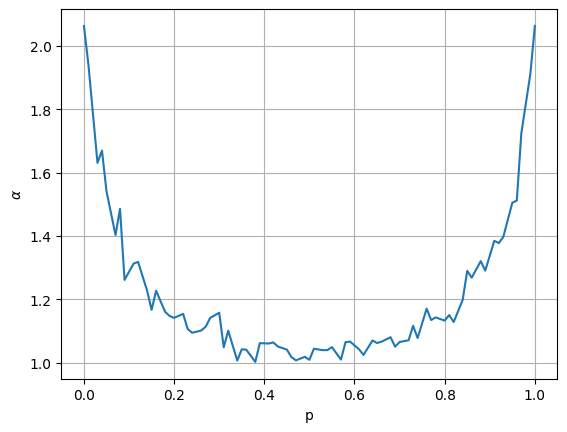

In [5]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'X'

TIMES = 50

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 75):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_circle_quantum_random_walk_1D(
            max_pos,
            steps,
            0.5,
            symm_qrw,
            noise_type,
            p,
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 101, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()

p noise: 0.000, alpha: 2.0625
p noise: 0.010, alpha: 1.9412
p noise: 0.030, alpha: 1.6332
p noise: 0.040, alpha: 1.6613
p noise: 0.050, alpha: 1.5370
p noise: 0.070, alpha: 1.4005
p noise: 0.080, alpha: 1.4820
p noise: 0.090, alpha: 1.2620
p noise: 0.110, alpha: 1.3137
p noise: 0.120, alpha: 1.3119
p noise: 0.140, alpha: 1.2106
p noise: 0.150, alpha: 1.1752
p noise: 0.160, alpha: 1.2158
p noise: 0.180, alpha: 1.1818
p noise: 0.190, alpha: 1.1516
p noise: 0.200, alpha: 1.1443
p noise: 0.220, alpha: 1.1452
p noise: 0.230, alpha: 1.1292
p noise: 0.240, alpha: 1.1080
p noise: 0.260, alpha: 1.1053
p noise: 0.270, alpha: 1.1138
p noise: 0.280, alpha: 1.1429
p noise: 0.300, alpha: 1.1796
p noise: 0.310, alpha: 1.0574
p noise: 0.320, alpha: 1.0813
p noise: 0.340, alpha: 1.0216
p noise: 0.350, alpha: 1.0410
p noise: 0.360, alpha: 1.0407
p noise: 0.380, alpha: 1.0160
p noise: 0.390, alpha: 1.0769
p noise: 0.410, alpha: 1.0727
p noise: 0.420, alpha: 1.0447
p noise: 0.430, alpha: 1.0671
p noise: 0

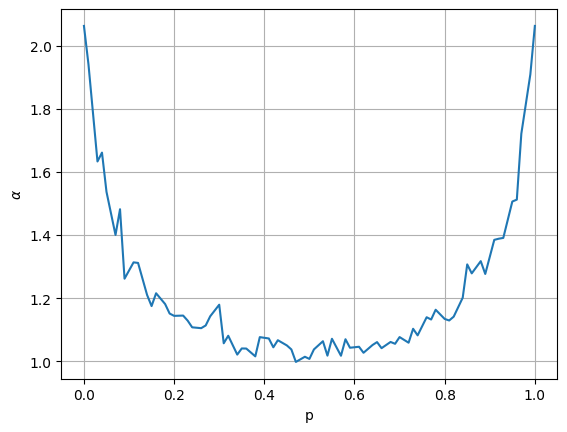

In [6]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'Z'

TIMES = 50

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 75):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_circle_quantum_random_walk_1D(
            max_pos,
            steps,
            0.5,
            symm_qrw,
            noise_type,
            p,
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 101, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()

p noise: 0.000, alpha: 2.0625
p noise: 0.010, alpha: 2.0208
p noise: 0.030, alpha: 1.9260
p noise: 0.040, alpha: 1.9356
p noise: 0.050, alpha: 1.8912
p noise: 0.070, alpha: 1.8436
p noise: 0.080, alpha: 1.8480
p noise: 0.090, alpha: 1.8087
p noise: 0.110, alpha: 1.8040
p noise: 0.120, alpha: 1.7915
p noise: 0.140, alpha: 1.7552
p noise: 0.150, alpha: 1.7550
p noise: 0.160, alpha: 1.7632
p noise: 0.180, alpha: 1.7302
p noise: 0.190, alpha: 1.7220
p noise: 0.200, alpha: 1.7025
p noise: 0.220, alpha: 1.6971
p noise: 0.230, alpha: 1.6904
p noise: 0.240, alpha: 1.6656
p noise: 0.260, alpha: 1.6744
p noise: 0.270, alpha: 1.6518
p noise: 0.280, alpha: 1.6494
p noise: 0.300, alpha: 1.6453
p noise: 0.310, alpha: 1.6125
p noise: 0.320, alpha: 1.6142
p noise: 0.340, alpha: 1.6011
p noise: 0.350, alpha: 1.5794
p noise: 0.360, alpha: 1.5886
p noise: 0.380, alpha: 1.5719
p noise: 0.390, alpha: 1.5534
p noise: 0.410, alpha: 1.5547
p noise: 0.420, alpha: 1.5329
p noise: 0.430, alpha: 1.5593
p noise: 0

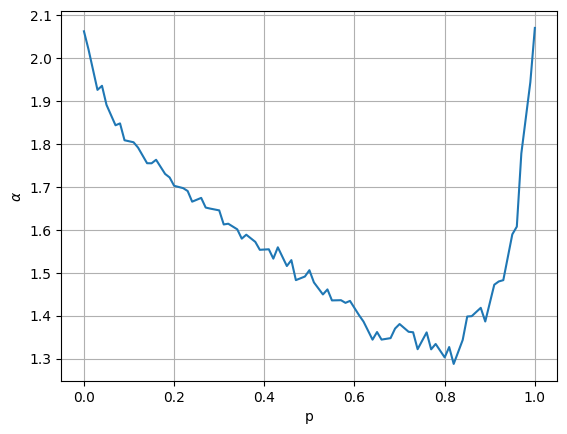

In [7]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'H'

TIMES = 50

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 75):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_circle_quantum_random_walk_1D(
            max_pos,
            steps,
            0.5,
            symm_qrw,
            noise_type,
            p,
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 101, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()

p noise: 0.000, alpha: 2.0625
p noise: 0.010, alpha: 2.0004
p noise: 0.030, alpha: 1.8191
p noise: 0.040, alpha: 1.8224
p noise: 0.050, alpha: 1.7512
p noise: 0.070, alpha: 1.6204
p noise: 0.080, alpha: 1.6611
p noise: 0.090, alpha: 1.5209
p noise: 0.110, alpha: 1.5418
p noise: 0.120, alpha: 1.4751
p noise: 0.140, alpha: 1.4212
p noise: 0.150, alpha: 1.4211
p noise: 0.160, alpha: 1.4206
p noise: 0.180, alpha: 1.3802
p noise: 0.190, alpha: 1.3454
p noise: 0.200, alpha: 1.3299
p noise: 0.220, alpha: 1.3150
p noise: 0.230, alpha: 1.3211
p noise: 0.240, alpha: 1.2551
p noise: 0.260, alpha: 1.2488
p noise: 0.270, alpha: 1.2271
p noise: 0.280, alpha: 1.2654
p noise: 0.300, alpha: 1.2439
p noise: 0.310, alpha: 1.1858
p noise: 0.320, alpha: 1.2104
p noise: 0.340, alpha: 1.1749
p noise: 0.350, alpha: 1.1709
p noise: 0.360, alpha: 1.1785
p noise: 0.380, alpha: 1.1496
p noise: 0.390, alpha: 1.1664
p noise: 0.410, alpha: 1.1528
p noise: 0.420, alpha: 1.1842
p noise: 0.430, alpha: 1.1494
p noise: 0

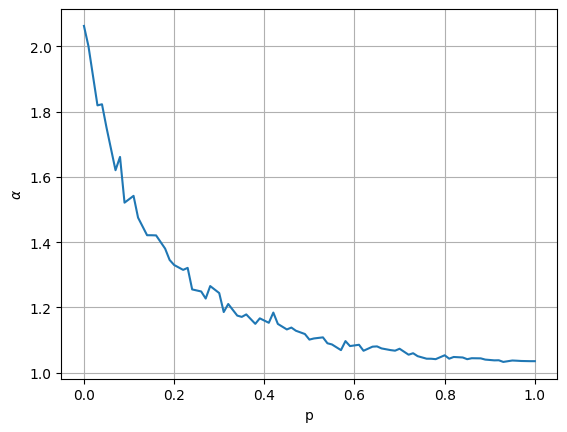

In [3]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'meas'

TIMES = 50

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 75):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_meas_circle_quantum_random_walk_1D(
            max_pos, 
            steps, 
            0.5, 
            symm_qrw, 
            p, 
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 101, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()